In [ ]:
## ============================================================================
## SECTION 1: Import Libraries
## ============================================================================
# All libraries are used in the script:
# - pandas: for data manipulation
# - numpy: for array operations
# - nibabel: for NIfTI file I/O
# - ants: for neuroimaging operations (ANTsPy)
# - os, fnmatch: for file system operations and pattern matching
# - tqdm_notebook: for progress bars (deprecated, but used)
# - matplotlib.pyplot: for visualization (optional, used in exploration cells)
import pandas as pd
import numpy as np
import nibabel as nib
import ants
import os, fnmatch
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt

In [ ]:
## ============================================================================
## SECTION 2: Load Metadata
## ============================================================================
# Load metadata file with PET-MRI pairs
# Old file reference (commented out): 'metafile_ADDLpipeline_abeta_mri_02_06_2024.csv'
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]

In [ ]:
## UNUSED CODE: Neuromorphometrics atlas (commented out, using Hammer atlas instead)
'''# Neuromorphometrics atlas
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii')

brain_labels = pd.read_xml('/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.xml',xpath=".//label")
brain_labels.reset_index(drop=True, inplace = True)
bm = ants.image_read('/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.nii').astype('uint32')
brain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()'''

'# Neuromorphometrics atlas\nmni_t1 = ants.image_read(\'/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii\')\n\nbrain_labels = pd.read_xml(\'/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.xml\',xpath=".//label")\nbrain_labels.reset_index(drop=True, inplace = True)\nbm = ants.image_read(\'/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.nii\').astype(\'uint32\')\nbrain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type=\'nearestNeighbor\').astype(\'uint32\').numpy()'

In [ ]:
## ============================================================================
## SECTION 3: Load Brain Atlas
## ============================================================================
## SECTION 3.1: Load Hammer Brain Atlas
# Load MNI152 T1 template and Hammer brain atlas
# Resample atlas to match template resolution
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')

bm = ants.image_read('/csc/epitkane/home/atagmazi/Hammer_brain_atlas/Hammers_mith_atlas_n30r83_SPM5.nii.gz').astype('uint32')
brain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()

In [5]:
brain_labels = ['Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Brainstem_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'Corp_Callosum_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'ThirdVentricl_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']

In [ ]:
## EXPLORATION CODE: Display mni_t1 image object (not needed for pipeline)
# mni_t1

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (182, 218, 182)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (91.0, 126.0, -72.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [ ]:
## EXPLORATION CODE: Display bm (brain mask) image object (not needed for pipeline)
# bm

ANTsImage (RPI)
	 Pixel Type : unsigned int (uint32)
	 Components : 1
	 Dimensions : (181, 217, 181)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-90.0, 126.0, -72.0)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [ ]:
## EXPLORATION CODE: Check brain_map dimensions (not needed for pipeline)
# brain_map.shape

(182, 218, 182)

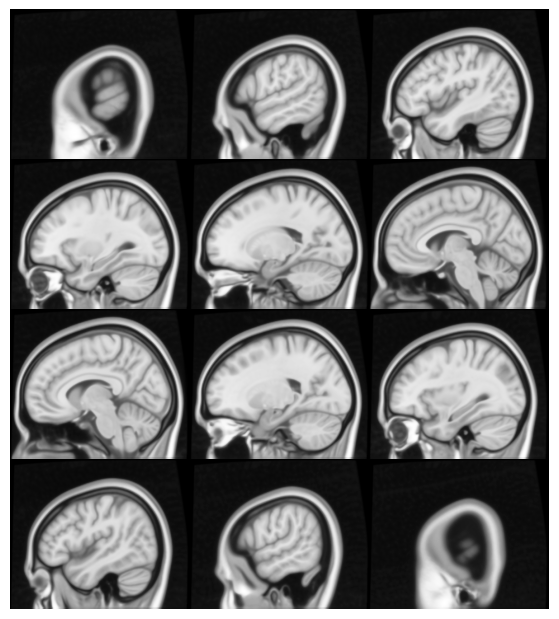

In [ ]:
## VISUALIZATION CODE: Plot MNI template (not needed for pipeline)
# ants.plot(mni_t1)

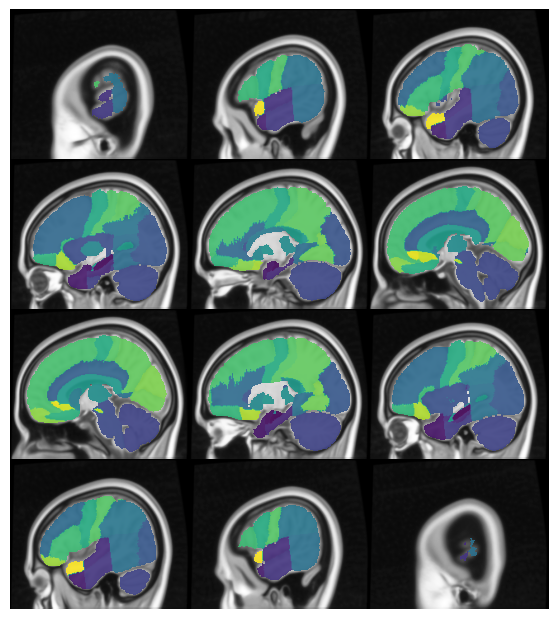

In [ ]:
## VISUALIZATION CODE: Plot MNI template with atlas overlay (not needed for pipeline)
# ants.plot(mni_t1, overlay= bm, cmap='Greys_r', overlay_cmap='viridis', overlay_alpha=0.9)

In [ ]:
## ============================================================================
## SECTION 4: Attach Registered PET Scan Paths
## ============================================================================
# Match Image.Data.ID to registered PET scan files
# Creates PATH_registered column with full file paths
for i in range(0,np.shape(meta)[0]):
    name = meta['Image.Data.ID'][i]+'_registered.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/'), name)
    if len(filename)> 0:
        meta.loc[i,'PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/' + filename[0]
        
    #print(i)

In [ ]:
## ============================================================================
## SECTION 5: Filter Scans with Valid Registered Paths
## ============================================================================
# Keep only rows where PATH_registered is not null
meta2 = meta[meta['PATH_registered'].notna()]
meta2.reset_index(drop=True, inplace = True)

In [ ]:
## ============================================================================
## SECTION 6: Create Brain Region Masks
## ============================================================================
## SECTION 6.1: Generate Masks for Each Brain Region
# Create binary masks for each unique brain region in the atlas
brain_areas = np.unique(brain_map)[1:]
area_masks = []
for area in tqdm_notebook(brain_areas):
    area_mask = np.zeros_like(brain_map)
    area_mask[brain_map == area] = 1
    #area_mask = resize_image(area_mask, mni_t1.numpy().shape, interpolation=0)
    area_masks.append(area_mask)
 

In [ ]:
## ============================================================================
## SECTION 6.2: Create Dictionary of Brain Region Masks
## ============================================================================
# Map brain region labels to their corresponding masks
brain_dict = {}
for i in range(len(brain_labels)):
    brain_dict[brain_labels[i]] = area_masks[i].copy()

In [ ]:
## ============================================================================
## SECTION 6.3: Define Preferred Order for Brain Regions
## ============================================================================
# Define order for organizing brain regions (used for merging left/right hemispheres)
prefered_order = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']

In [ ]:
## ============================================================================
## SECTION 6.4: Reorder Brain Dictionary
## ============================================================================
# Reorder brain_dict according to prefered_order
brain_dict_ordered = {}
for i in range(len(prefered_order)):
    brain_dict_ordered[prefered_order[i]] = brain_dict[prefered_order[i]]

In [ ]:
## ============================================================================
## SECTION 6.5: Define Merged Labels (Left+Right Combined)
## ============================================================================
# Labels for merged brain regions (left and right hemispheres combined)
brain_labels_merged = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_sum',
'Amygdala_sum',
'Ant_TL_med_sum',
'Ant_TL_inf_lat_sum',
'G_paraH_amb_sum',
'G_sup_temp_cent_sum',
'G_tem_midin_sum',
'G_occtem_la_sum',
'Cerebellum_sum',
'Insula_sum',
'OL_rest_lat_sum',
'G_cing_ant_sup_sum',
'G_cing_post_sum',
'FL_mid_fr_G_sum',
'PosteriorTL_sum',
'PL_rest_sum',
'CaudateNucl_sum',
'NuclAccumb_sum',
'Putamen_sum',
'Thalamus_sum',
'Pallidum_sum',
'FrontalHorn_sum',
'TemporaHorn_sum',
'FL_precen_G_sum',
'FL_strai_G_sum',
'FL_OFC_AOG_sum',
'FL_inf_fr_G_sum',
'FL_sup_fr_G_sum',
'PL_postce_G_sum',
'PL_sup_pa_G_sum',
'OL_ling_G_sum',
'OL_cuneus_sum',
'FL_OFC_MOG_sum',
'FL_OFC_LOG_sum',
'FL_OFC_POG_sum',
'S_nigra_sum',
'Subgen_antCing_sum',
'Subcall_area_sum',
'Presubgen_antCing_sum',
'G_sup_temp_ant_sum']

In [ ]:
## ============================================================================
## SECTION 6.6: Merge Left and Right Hemisphere Masks
## ============================================================================
# Merge right and left hemisphere masks from Hammer atlas
# First 3 regions are already merged (no left/right), then merge pairs
brain_dict_merged = {}
for i in range(0,3):
    brain_dict_merged[brain_labels_merged[i]] = brain_dict_ordered[prefered_order[i]]

name = 3
for i in range(3,len(prefered_order),2):
    brain_dict_merged[brain_labels_merged[name]] = brain_dict_ordered[prefered_order[i]] + brain_dict_ordered[prefered_order[i+1]]
    name +=1

(-0.5, 181.5, 181.5, -0.5)

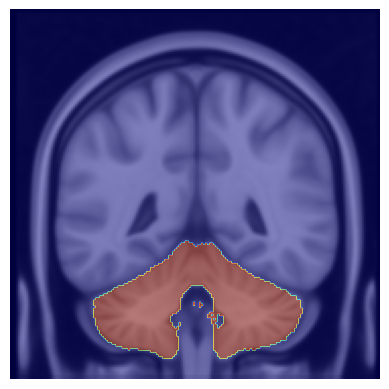

In [ ]:
## VISUALIZATION CODE: Display cerebellum mask overlay (not needed for pipeline)
# plt.imshow(np.rot90(mni_t1[:, 80, :].copy()), cmap = 'gray')
# plt.imshow(np.rot90(brain_dict_merged['Cerebellum_sum'][:, 80, :].copy()), cmap = 'jet',alpha = 0.5) 
# plt.axis('off')

In [ ]:
## ============================================================================
## SECTION 7: Extract Cerebellum Mask
## ============================================================================
# Extract cerebellum mask for normalization
Cerebellum = brain_dict_merged['Cerebellum_sum']

In [ ]:
## ============================================================================
## SECTION 8: Define Normalization Function
## ============================================================================
# Normalize PET scan by dividing by mean cerebellum intensity
# Returns normalized PET scan (SUVR - Standardized Uptake Value Ratio)
def get_cerebellum_intensity(pet_scan):
    cerebellum_intensity = np.sum(pet_scan * Cerebellum)/np.sum(Cerebellum)
    pet_normalised = pet_scan/cerebellum_intensity
    return pet_normalised

In [ ]:
## TEST CODE: Test normalization on first 3 scans (not needed for pipeline)
# summary_before = []
# summary_after = []
# failed = []
# for img in meta2.loc[:2,'PATH_registered']: 
#     imag=nib.load(meta2.loc[0,'PATH_registered'])
#     image = imag.get_fdata()
#     summary_before.append(np.isnan(image).any())
#     image_norm = get_cerebellum_intensity(image)
#     image_norm[image_norm<0] = 0
#     minimum = np.min(image_norm)
#     maximum = np.max(image_norm)
#     #image_norm = image_norm - minimum
#     summary_after.append(np.isnan(image_norm).any())
#     if np.isnan(image).any() or np.isnan(image_norm).any():
#         failed.append(meta2.loc[i,'Image.ID'])

In [ ]:
## ============================================================================
## SECTION 9: Normalize All PET Scans
## ============================================================================
# Main processing loop: normalize all PET scans using cerebellum intensity
# NOTE: Run in Jupyter notebook (slurm returned error, but manageable for notebook)
# For each scan:
#   1. Load registered PET scan
#   2. Normalize by cerebellum intensity
#   3. Set negative values to 0
#   4. Save normalized scan
max_intensity = []
min_intensity = []
median_intensity = []
zeros = []
failed = []
#meta2['maximum_intensity'] = 0
cerebel = []
i = 0

summary_before = []
summary_after = []
for img in meta2.loc[:,'PATH_registered']: #!!
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    if len(image_norm[image_norm<0])>0:
        zeros.append(meta2.loc[i,'Project'])
    image_norm[image_norm<0] = 0
    summary_after.append(np.isnan(image_norm).any())
    
    if np.isnan(image).any() or np.isnan(image_norm).any():
        failed.append(meta2.loc[i,'Image.ID'])
    #minimum = np.min(image_norm)
    #image_norm = image_norm - minimum
    nii_image = nib.Nifti1Image(image_norm, imag.affine, imag.header)
    nib.save(nii_image, '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' 
             + meta2.loc[i,'Image.Data.ID']+'_normalised.nii')
    max_intensity.append(np.max(image_norm))
    min_intensity.append(np.min(image_norm))
    print(i)
    i+=1

In [ ]:
## OPTIONAL: Exit script (useful when running on cluster)
# sys.exit()